In [1]:
import numpy as np
from getdist import loadMCSamples, plots
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
def MCResult_cobaya(gdsamples, file):
    stats = gdsamples.getMargeStats()

    for par in stats.names[:gdsamples.samples.shape[1]-2]:
        par_stats = stats.parWithName(par.name)
        mean = par_stats.mean

        # Erros de 1-sigma (68% CL)
        lower_1s = par_stats.limits[0].lower
        upper_1s = par_stats.limits[0].upper
        err_plus_1s = upper_1s - mean
        err_minus_1s = mean - lower_1s

        # Erros de 2-sigma (95% CL)
        lower_2s = par_stats.limits[1].lower
        upper_2s = par_stats.limits[1].upper
        err_plus_2s = upper_2s - mean
        err_minus_2s = mean - lower_2s
            
        label = f"{par.name}"
            
        print(f"{label} = {mean:.4f} +{err_plus_1s:.4f} +{err_plus_2s:.4f} -{err_plus_1s:.4f} -{err_plus_2s:.4f}")

    with open(file, 'r') as f:
        lines = f.readlines()
        logz = float(lines[1].replace("logZ: ", ""))
        std = float(lines[2].replace("logZstd: ", ""))
        print("\nEvidência Bayesiana:")
        print(f"logZ = {logz:.3f} +/- {std:.3f}")

def build_data(datafile,SH0ES):
    """
    Run once at the start to load in the data vectors.
    
    Returns x, y where x is the independent variable (redshift in this case)
    and y is the Gaussian-distribured measured variable (magnitude in this case).
    """
    
    global origlen, wwPS, wwPPlus, cepheid_distance, is_calibrator, zHELPS, zHELPPlus

    print("Loading data from {}".format(datafile))
    data = pd.read_csv(datafile, sep=r'\s+')
    origlen = len(data)
    
    if SH0ES:
        ww = (data['zHD']>0.01) | (np.array(data['IS_CALIBRATOR'],dtype=bool))
        wwPS = ww
        zHELPS = data['zHEL'][ww]
    else:
        ww = (data['zHD']>0.01)
        wwPPlus = ww
        zHELPPlus = data['zHEL'][ww]

    zCMB = data['zHD'][ww] #use the vpec corrected redshift for zCMB 
    
    m_obs = data['m_b_corr'][ww]
    if SH0ES:
        is_calibrator = data['IS_CALIBRATOR'][ww]
        cepheid_distance = data['CEPH_DIST'][ww]

    return zCMB, m_obs

def build_covariance(covdatafile, SH0ES):
    """
    Run once at the start to build the covariance matrix for the data
    The file format for the covariance has the first line as an integer
    indicating the number of covariance elements, and the the subsequent
    lines being the elements.
    This function reads in the file and the nasty for loops trim down the covariance
    to match the only rows of data that are used for cosmology    
    """
    print("Loading covariance from {}".format(covdatafile))


    f = open(covdatafile)
    line = f.readline()
    if SH0ES:
        n = int(len(zCMBPS))
        ww = wwPS
    else:
        n = int(len(zCMBPPlus))
        ww = wwPPlus
    C = np.zeros((n,n))
    ii = -1
    jj = -1
    mine = 999
    maxe = -999
    for i in range(origlen):
        jj = -1
        if ww[i]:
            ii += 1
        for j in range(origlen):
            if ww[j]:
                jj += 1
            val = float(f.readline())
            if ww[i]:
                if ww[j]:
                    C[ii,jj] = val
    f.close()
    
    print('Done')

        # Return the covariance; the parent class knows to invert this
        # later to get the precision matrix that we need for the likelihood.
    return C

def deltaBIC(samples, n, k):
    chi2min = np.min(samples.getParams().chi2)
    bic = chi2min + k*np.log(n)
    return bic, chi2min

In [3]:
zHz, _, _ = np.genfromtxt('data/32CCdata.dat', comments='#', usecols=(0,1,2), unpack=True, delimiter=',')
zCMBPS, _ = build_data('data/Pantheon+SH0ES.dat',SH0ES=True)
zCMBPPlus, _ = build_data('data/Pantheon+SH0ES.dat',SH0ES=False)
CCPPlusData = len(zHz)+len(zCMBPPlus)
CCPSData = len(zHz)+len(zCMBPS)

Loading data from data/Pantheon+SH0ES.dat
Loading data from data/Pantheon+SH0ES.dat


# Resultados

## P21
### CC+Pantheon+

In [4]:
samplesPPHz_21 = loadMCSamples("chains/P21/PP/PPHz_21")
logzPP21 = "chains/P21/PP/PPHz_21.logZ"

chains/P21/PP/PPHz_21.1.txt
Removed no burn in


In [9]:
bicPP_21, chi2PP_21 = deltaBIC(samplesPPHz_21, CCPPlusData, 4)

In [11]:
MCResult_cobaya(samplesPPHz_21, logzPP21)
print(f"\nBIC = {bicPP_21}")
print(f"chi2min = {chi2PP_21}")

M = 0.2662 +19.2338 +19.2338 -19.2338 -19.2338
h0 = 68.0085 +3.7953 +7.6819 -3.7953 -7.6819
q0 = -0.4072 +0.0342 +0.0709 -0.0342 -0.0709
j0 = 0.4513 +0.0726 +0.1170 -0.0726 -0.1170

Evidência Bayesiana:
logZ = -719.510 +/- 0.173

BIC = 1447.6207609387016
chi2min = 1418.0551


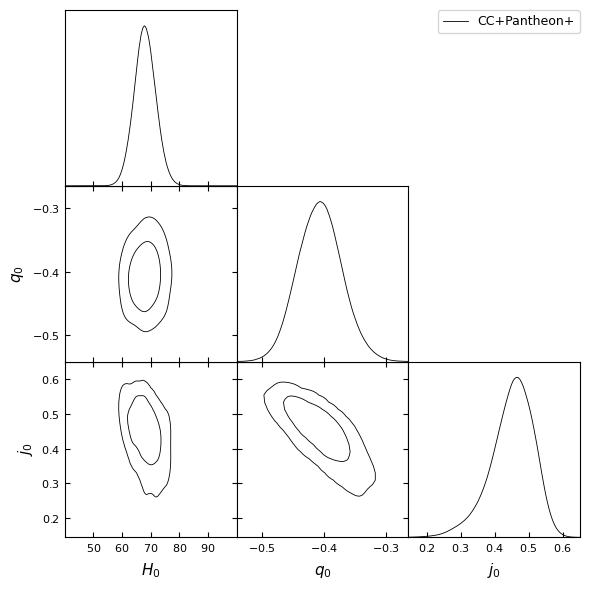

In [7]:
gPPHz21 = plots.getSubplotPlotter()
gPPHz21.triangle_plot([samplesPPHz_21], ["h0", "q0", "j0"], filled=False, legend_labels=["CC+Pantheon+"])
plt.show()

### CC+Pantheon+SH0ES

In [19]:
samplesPSHz_21 = loadMCSamples("chains/P21/PS/PSHz_21")
logzPS21 = "chains/P21/PS/PSHz_21.logZ"

In [63]:
bicPS_21 = deltaBIC(samplesPSHz_21, CCPSData, 4)

In [25]:
MCResult_cobaya(samplesPSHz_21, logzPS21)

M = -19.2530 +0.0280 +0.0560 -0.0280 -0.0560
h0 = 72.9837 +0.9692 +1.9925 -0.9692 -1.9925
q0 = -0.4085 +0.0329 +0.0708 -0.0329 -0.0708
j0 = 0.4269 +0.0713 +0.1155 -0.0713 -0.1155

Evidência Bayesiana:
logZ = -754.064 +/- 0.250


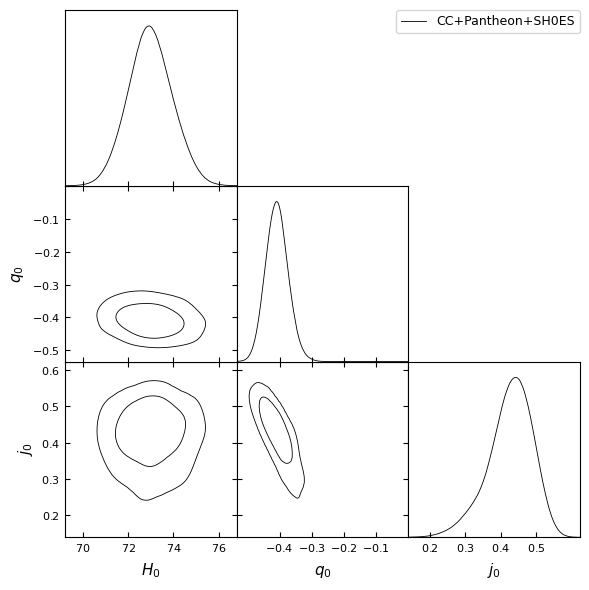

In [26]:
gPSHz21 = plots.getSubplotPlotter()
gPSHz21.triangle_plot([samplesPSHz_21], ["h0", "q0", "j0"], filled=False, legend_labels=["CC+Pantheon+SH0ES"])
plt.show()

## P22

### CC+Pantheon+
#### -4 <s0 < 4

In [22]:
samplesPPHz_22 = loadMCSamples("chains/P22/PP/PPHz_22")
logzPP22 = "chains/P22/PP/PPHz_22.logZ"

In [64]:
bicPP_22 = deltaBIC(samplesPPHz_22, CCPPlusData, 5)

In [9]:
MCResult_cobaya(samplesPPHz_22, logzPP22)

M = 0.1244 +19.3756 +19.3756 -19.3756 -19.3756
h0 = 68.2092 +3.7798 +7.4730 -3.7798 -7.4730
q0 = -0.4754 +0.0578 +0.1330 -0.0578 -0.1330
j0 = 1.0502 +0.4179 +0.6994 -0.4179 -0.6994
s0 = 1.6931 +2.3069 +2.3069 -2.3069 -2.3069

Evidência Bayesiana:
logZ = -717.398 +/- 0.136


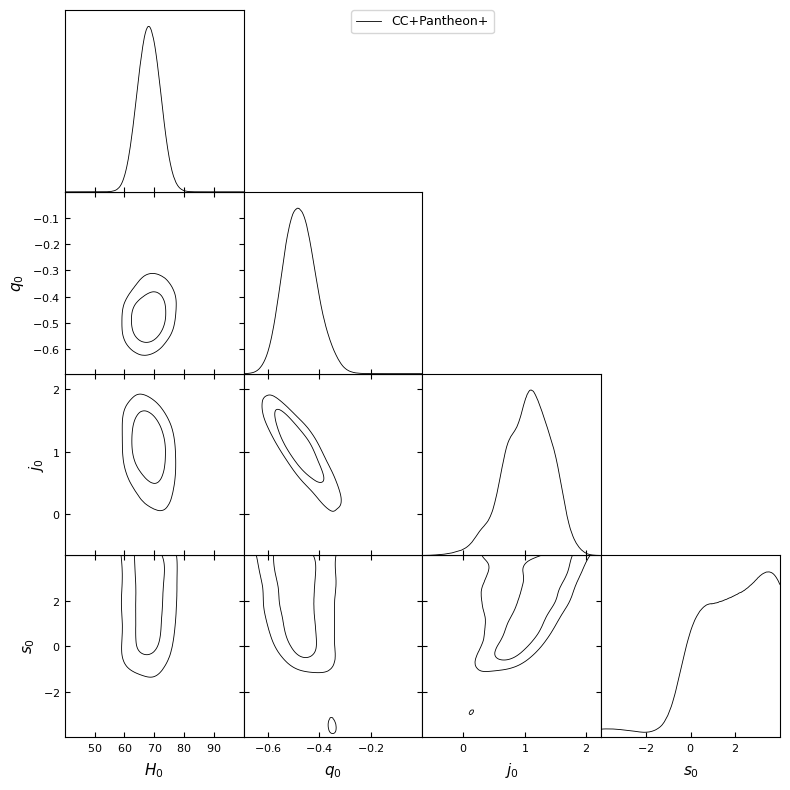

In [10]:
gPPHz22 = plots.getSubplotPlotter()
gPPHz22.triangle_plot([samplesPPHz_22], ["h0", "q0", "j0", "s0"], filled=False, legend_labels=["CC+Pantheon+"])
plt.show()

#### $-50<q_{0}<50$

chains/P22/PP/PPHz_22.1.txt
Removed no burn in
M = -0.3226 +19.8226 +19.8226 -19.8226 -19.8226
h0 = 68.9329 +3.6112 +7.2350 -3.6112 -7.2350
q0 = -0.5190 +0.1035 +0.2076 -0.1035 -0.2076
j0 = 2.2460 +1.7732 +2.4625 -1.7732 -2.4625
s0 = 21.3253 +28.6747 +28.6747 -28.6747 -28.6747

Evidência Bayesiana:
logZ = -716.863 +/- 0.124


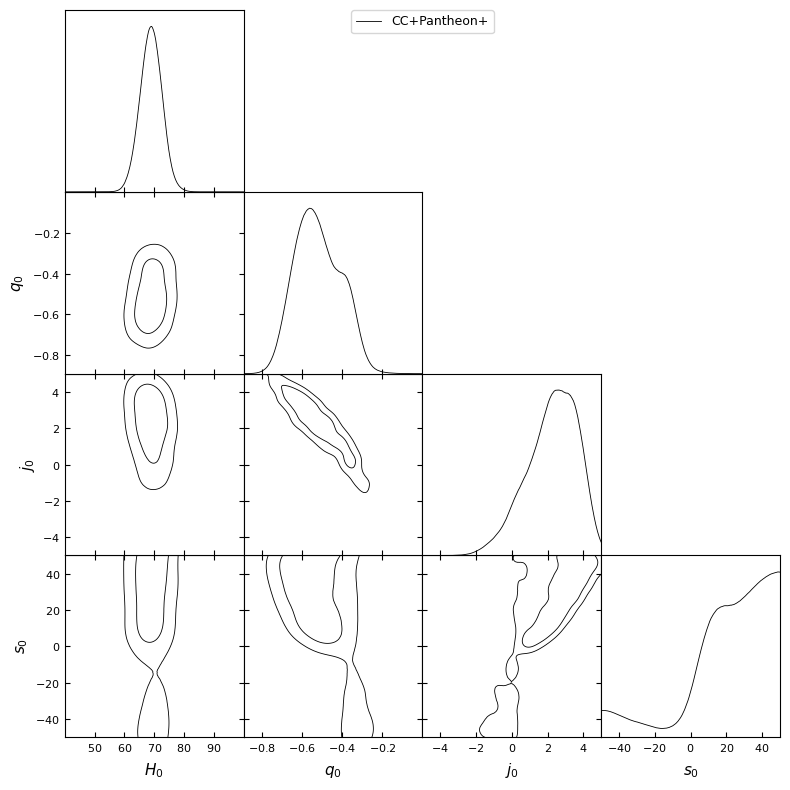

In [4]:
samplesPPHz_22 = loadMCSamples("chains/P22/PP/PPHz_22")
logzPP22 = "chains/P22/PP/PPHz_22.logZ"

MCResult_cobaya(samplesPPHz_22, logzPP22)

gPPHz22 = plots.getSubplotPlotter()
gPPHz22.triangle_plot([samplesPPHz_22], ["h0", "q0", "j0", "s0"], filled=False, legend_labels=["CC+Pantheon+"])
plt.show()

### CC+Pantheon+SH0ES

In [48]:
samplesPSHz_22 = loadMCSamples("chains/P22/PS/PSHz_22")
logzPS22 = "chains/P22/PS/PSHz_22.logZ"

chains/P22/PS/PSHz_22.1.txt
Removed no burn in


In [65]:
bicPS_22 = deltaBIC(samplesPSHz_22, CCPSData, 5)

In [50]:
MCResult_cobaya(samplesPSHz_22, logzPS22)

M = -19.2521 +0.0274 +0.0562 -0.0274 -0.0562
h0 = 73.1417 +0.9724 +1.9213 -0.9724 -1.9213
q0 = -0.4950 +0.1372 +0.1911 -0.1372 -0.1911
j0 = 1.9281 +1.7992 +2.4685 -1.7992 -2.4685
s0 = 21.2579 +28.7421 +28.7421 -28.7421 -28.7421

Evidência Bayesiana:
logZ = -751.927 +/- 0.213


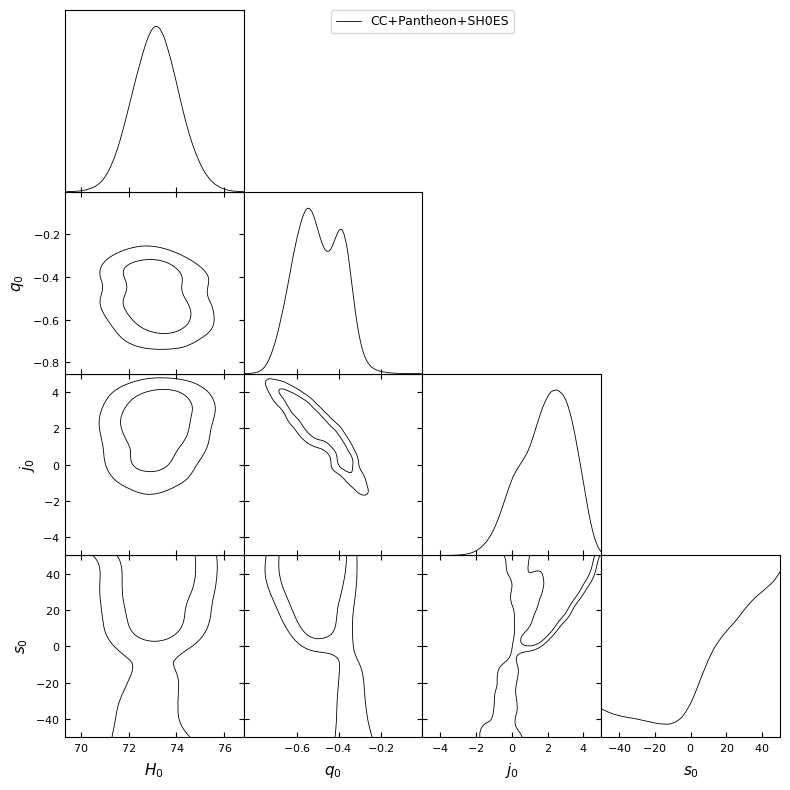

In [51]:
gPSHz22 = plots.getSubplotPlotter()
gPSHz22.triangle_plot([samplesPSHz_22], ["h0", "q0", "j0", "s0"], filled=False, legend_labels=["CC+Pantheon+SH0ES"])
plt.show()

## P31
### CC+Pantheon+

In [30]:
samplesPPHz_31 = loadMCSamples("chains/P31/PP/PPHz_31")
logzPP31 = "chains/P31/PP/PPHz_31.logZ"

In [66]:
bicPP_31 = deltaBIC(samplesPPHz_31, CCPPlusData, 5)

In [15]:
MCResult_cobaya(samplesPPHz_31, logzPP31)

M = -0.1269 +19.6269 +19.6269 -19.6269 -19.6269
h0 = 67.7619 +3.6557 +7.5044 -3.6557 -7.5044
q0 = -0.3178 +0.0664 +0.1393 -0.0664 -0.1393
j0 = -0.4474 +0.8332 +1.0423 -0.8332 -1.0423
s0 = -3.1796 +3.0270 +3.0650 -3.0270 -3.0650

Evidência Bayesiana:
logZ = -720.649 +/- 0.142


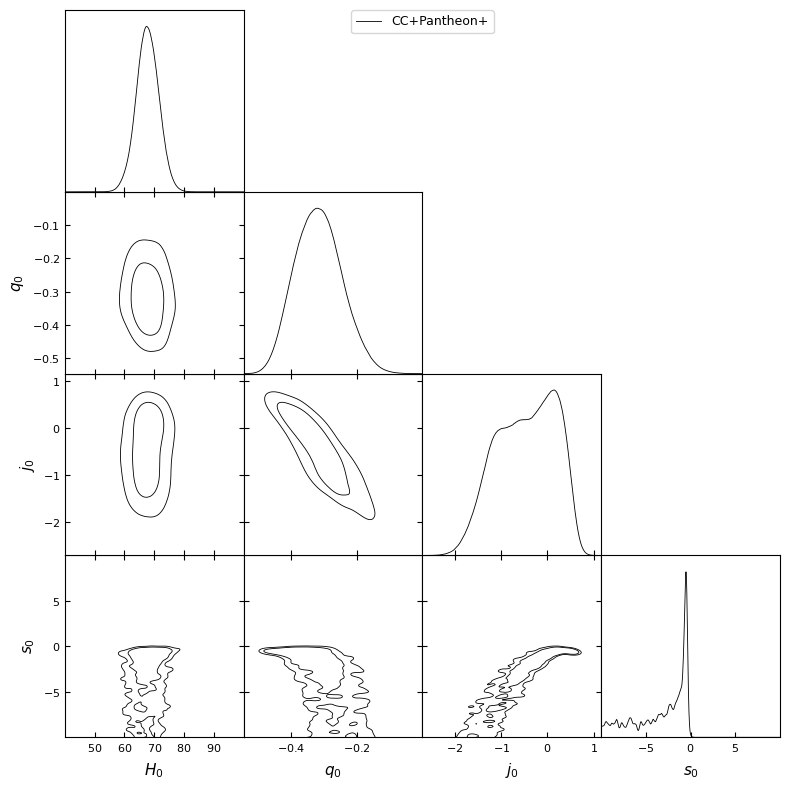

In [16]:
gPPHz31 = plots.getSubplotPlotter()
gPPHz31.triangle_plot([samplesPPHz_31], ["h0", "q0", "j0", "s0"], filled=False, legend_labels=["CC+Pantheon+"])
plt.show()

### C++Pantheon+SH0ES

In [32]:
samplesPSHz_31 = loadMCSamples("chains/P31/PS/PSHz_31")
logzPS31 = "chains/P31/PS/PSHz_31.logZ"

In [67]:
bicPS_31 = deltaBIC(samplesPSHz_31, CCPSData, 5)

In [18]:
MCResult_cobaya(samplesPSHz_31, logzPS31)

M = -19.2541 +0.0278 +0.0544 -0.0278 -0.0544
h0 = 72.7906 +0.9738 +1.8134 -0.9738 -1.8134
q0 = -0.3314 +0.0638 +0.1433 -0.0638 -0.1433
j0 = -0.2917 +0.8658 +0.9436 -0.8658 -0.9436
s0 = -2.3947 +2.3183 +2.1357 -2.3183 -2.1357

Evidência Bayesiana:
logZ = -756.366 +/- 0.232


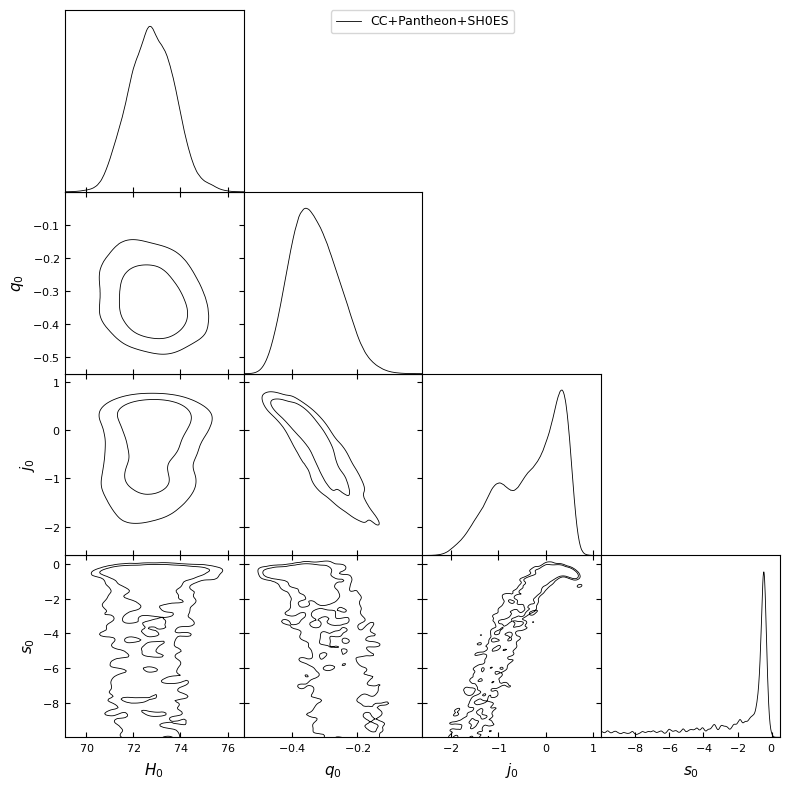

In [19]:
gPSHz31 = plots.getSubplotPlotter()
gPSHz31.triangle_plot([samplesPSHz_31], ["h0", "q0", "j0", "s0"], filled=False, legend_labels=["CC+Pantheon+SH0ES"])
plt.show()

# Comparação CC+Pantheon+

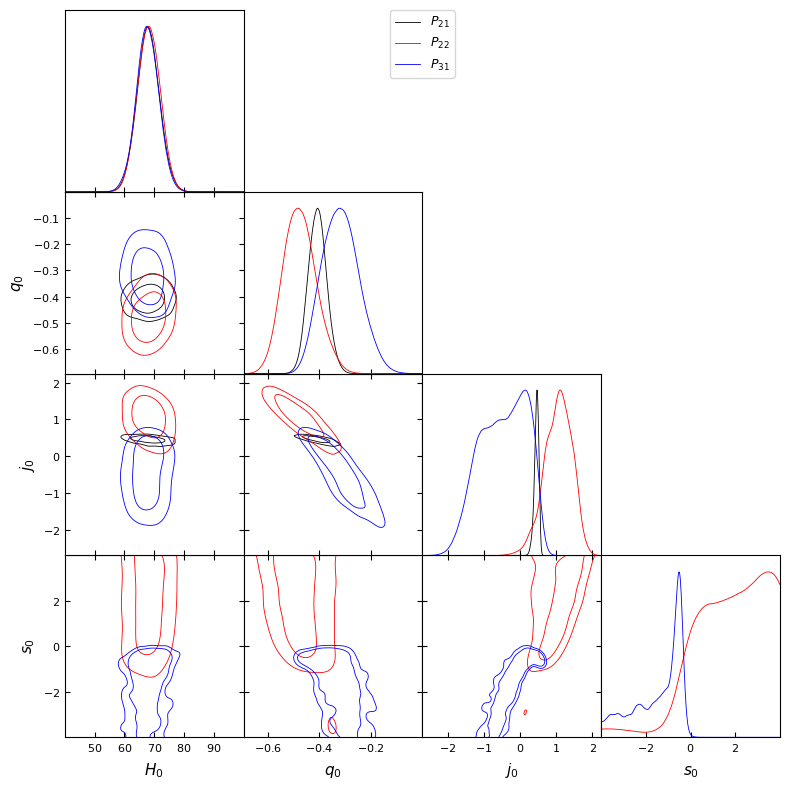

In [31]:
gPPHz = plots.getSubplotPlotter()
gPPHz.triangle_plot([samplesPPHz_21, samplesPPHz_22, samplesPPHz_31], ["h0", "q0", "j0", "s0"], filled=False, legend_labels=["$P_{21}$", "$P_{22}$", "$P_{31}$"])
plt.show()

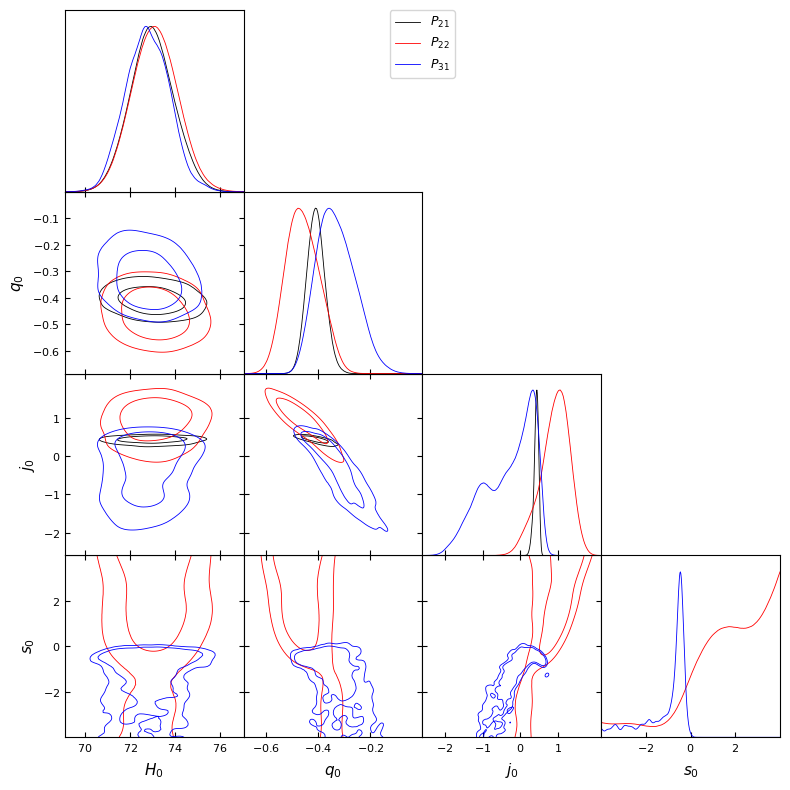

In [39]:
gPSHz = plots.getSubplotPlotter()
gPSHz.triangle_plot([samplesPSHz_21, samplesPSHz_22, samplesPSHz_31], ["h0", "q0", "j0", "s0"], filled=False, legend_labels=["$P_{21}$", "$P_{22}$", "$P_{31}$"])
plt.show()

## P32

### CC+Pantheon+

In [54]:
samplesPPHz_P32 = loadMCSamples("chains/P32/PP/PPHz_32")
logzPP32 = "chains/P32/PP/PPHz_32.logZ"

In [68]:
bicPP_32 = deltaBIC(samplesPPHz_P32, CCPPlusData, 6)

In [55]:
MCResult_cobaya(samplesPPHz_P32, logzPP32)

M = -0.8916 +20.3916 +20.3916 -20.3916 -20.3916
h0 = 68.2083 +4.0113 +7.9181 -4.0113 -7.9181
q0 = -0.4714 +0.1007 +0.1782 -0.1007 -0.1782
j0 = 1.0355 +0.9212 +1.7067 -0.9212 -1.7067
s0 = 1.8385 +5.1087 +7.4311 -5.1087 -7.4311
l0 = 16.8419 +43.1581 +43.1581 -43.1581 -43.1581

Evidência Bayesiana:
logZ = -719.488 +/- 0.157


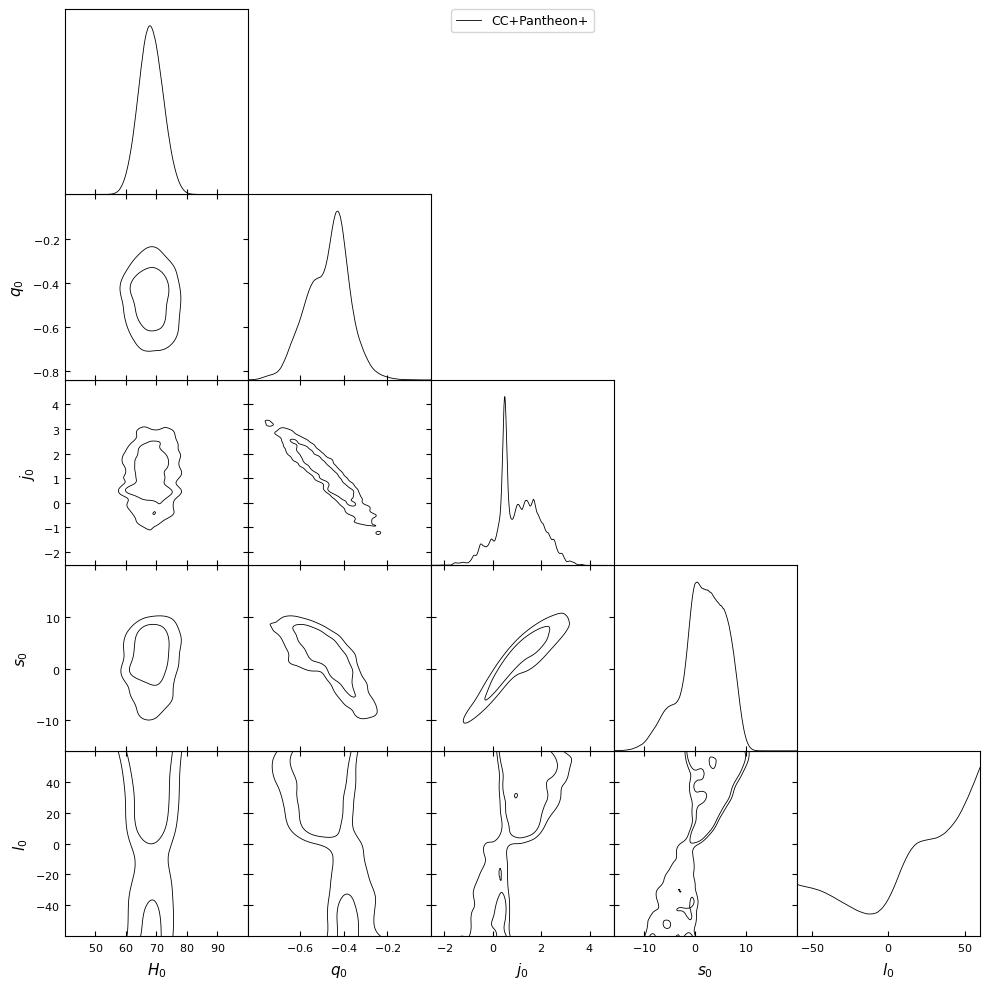

In [56]:
gPPHzP32 = plots.getSubplotPlotter()
gPPHzP32.triangle_plot([samplesPPHz_P32], ["h0", "q0", "j0", "s0", "l0"], filled=False, legend_labels=["CC+Pantheon+"])
plt.show()

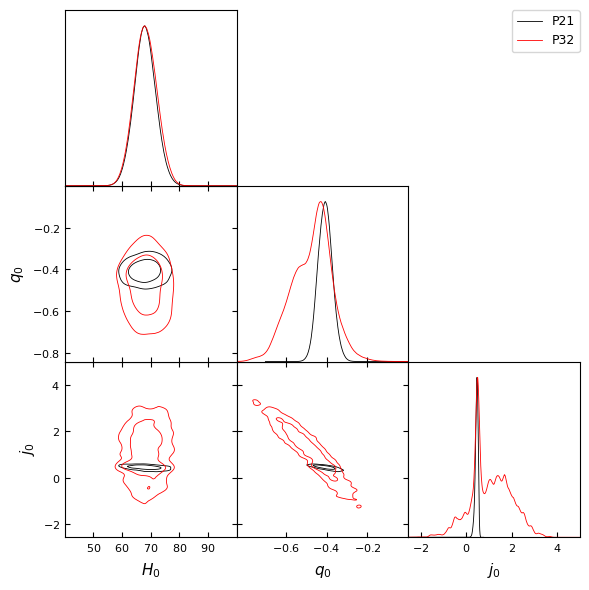

In [71]:
gPPHzP32P21 = plots.getSubplotPlotter()
gPPHzP32P21.triangle_plot([samplesPPHz_21, samplesPPHz_P32], ["h0", "q0", "j0"], filled=False, legend_labels=["P21", "P32"])
plt.show()

### CC+Pantheon+SH0ES

In [73]:
samplesPSHz_32 = loadMCSamples("chains/P32/PS/PSHz_32")
logzPS32 = "chains/P32/PS/PSHz_32.logZ"

chains/P32/PS/PSHz_32.1.txt
Removed no burn in


In [80]:
bicPS_32 = deltaBIC(samplesPSHz_32, CCPSData, 6)

In [74]:
MCResult_cobaya(samplesPSHz_32, logzPS32)

M = -19.2529 +0.0267 +0.0570 -0.0267 -0.0570
h0 = 73.2109 +0.9139 +2.0178 -0.9139 -2.0178
q0 = -0.5163 +0.1015 +0.1553 -0.1015 -0.1553
j0 = 1.5711 +0.6125 +1.5851 -0.6125 -1.5851
s0 = 5.9361 +4.2896 +6.9338 -4.2896 -6.9338
l0 = 54.2297 +45.7703 +45.7703 -45.7703 -45.7703

Evidência Bayesiana:
logZ = -754.424 +/- 0.232


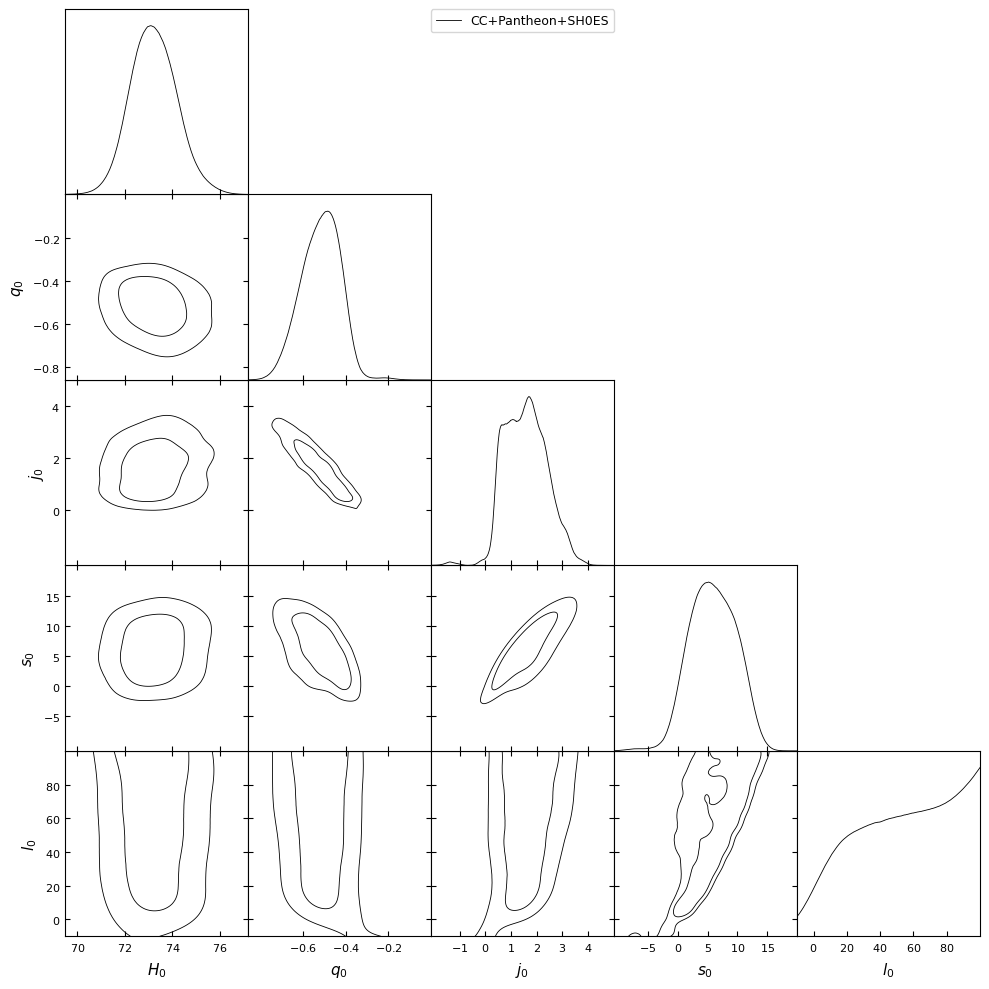

In [75]:
gPSHz32= plots.getSubplotPlotter()
gPSHz32.triangle_plot([samplesPSHz_32], ["h0", "q0", "j0", "s0", "l0"], filled=False, legend_labels=["CC+Pantheon+SH0ES"])
plt.show()

## Comparação dos P32

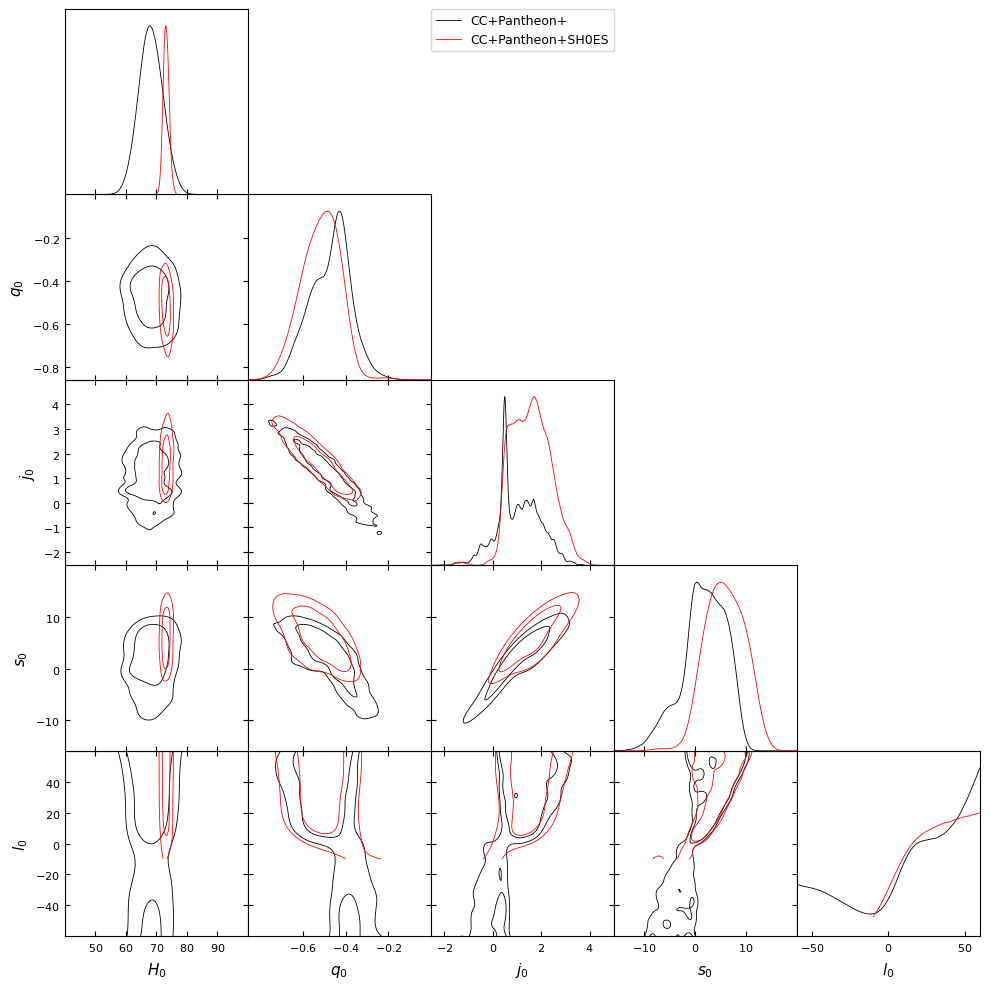

In [83]:
gPPPSHz_32 = plots.getSubplotPlotter()
gPPPSHz_32.triangle_plot([samplesPPHz_P32, samplesPSHz_32], ["h0", "q0", "j0", "s0", "l0"], filled=False, legend_labels=["CC+Pantheon+", "CC+Pantheon+SH0ES"])
plt.show()

# Comparação das evidências
## CC+Pantheon+

In [86]:
dPP21 = np.round(float(open(logzPP21,'r').readlines()[1].replace("logZ: ", "")) - float(open(logzPP21,'r').readlines()[1].replace("logZ: ", "")),2)
dPP22 = np.round(float(open(logzPP22,'r').readlines()[1].replace("logZ: ", "")) - float(open(logzPP21,'r').readlines()[1].replace("logZ: ", "")),2)
dPP31 = np.round(float(open(logzPP31,'r').readlines()[1].replace("logZ: ", "")) - float(open(logzPP21,'r').readlines()[1].replace("logZ: ", "")),2)
dPP32 = np.round(float(open(logzPP32,'r').readlines()[1].replace("logZ: ", "")) - float(open(logzPP21,'r').readlines()[1].replace("logZ: ", "")),2)

In [87]:
print(f"Bayesian evidence:\nDeltaP21 = {dPP21} \nDeltaP22 = {dPP22} \nDeltaP31 = {dPP31} \nDeltaP32 = {dPP32}")

Bayesian evidence:
DeltaP21 = 0.0 
DeltaP22 = 2.65 
DeltaP31 = -1.14 
DeltaP32 = 0.12


In [70]:
BIC_P21 = np.round(np.absolute(bicPP_21 - bicPP_21),2)
BIC_P22 = np.round(np.absolute(bicPP_22 - bicPP_21),2)
BIC_P31 = np.round(np.absolute(bicPP_31 - bicPP_21),2)
BIC_P32 = np.round(np.absolute(bicPP_32 - bicPP_21),2)
print(f"BIC:\nDeltaP21 = {BIC_P21}\nDeltaP22 = {BIC_P22}\nDeltaP31 = {BIC_P31}\nDeltaP32 = {BIC_P32}")

BIC:
DeltaP21 = 0.0
DeltaP22 = 6.63
DeltaP31 = 6.41
DeltaP32 = 13.28


## CC+Pantheon+SH0ES

In [88]:
dPS21 = np.round(float(open(logzPS21,'r').readlines()[1].replace("logZ: ", "")) - float(open(logzPS21,'r').readlines()[1].replace("logZ: ", "")),2)
dPS22 = np.round(float(open(logzPS22,'r').readlines()[1].replace("logZ: ", "")) - float(open(logzPS21,'r').readlines()[1].replace("logZ: ", "")),2)
dPS31 = np.round(float(open(logzPS31,'r').readlines()[1].replace("logZ: ", "")) - float(open(logzPS21,'r').readlines()[1].replace("logZ: ", "")),2)
dPS32 = np.round(float(open(logzPS32,'r').readlines()[1].replace("logZ: ", "")) - float(open(logzPS21,'r').readlines()[1].replace("logZ: ", "")),2)

In [89]:
print(f"Bayesian evidence:\nDeltaP21 = {dPS21} \nDeltaP22 = {dPS22} \nDeltaP31 = {dPS31}\nDeltaP32 = {dPS32}")

Bayesian evidence:
DeltaP21 = 0.0 
DeltaP22 = 2.14 
DeltaP31 = -2.3
DeltaP32 = -0.36


In [81]:
BIC_P21 = np.round(np.absolute(bicPS_21 - bicPS_21),2)
BIC_P22 = np.round(np.absolute(bicPS_22 - bicPS_21),2)
BIC_P31 = np.round(np.absolute(bicPS_31 - bicPS_21),2)
BIC_P32 = np.round(np.absolute(bicPS_32 - bicPS_21), 2)
print(f"BIC:\nDeltaP21 = {BIC_P21}\nDeltaP22 = {BIC_P22}\nDeltaP31 = {BIC_P31}\nDeltaP32 = {BIC_P32}")

BIC:
DeltaP21 = 0.0
DeltaP22 = 3.92
DeltaP31 = 6.53
DeltaP32 = 14.09
